Погрешности методов:
Метод Эйлера (h = 0.1): 41.15450995
Метод Эйлера (h = 0.05): 27.95326032
Метод Рунге-Кутты 4-го порядка (h = 0.1): 1.56796772
Метод Рунге-Кутты 4-го порядка (h = 0.05): 0.45934688
Метод степенных рядов (n = 4): 37.86542792
Метод последовательных приближений (n = 3): 47.86472363

Таблица значений:
   x   |   Точное   |  Эйлер h=0.1 |  Эйлер h=0.05 |   РК4 h=0.1  |  РК4 h=0.05  | Степ. ряды | Посл. прибл.
-------|------------|--------------|--------------|--------------|--------------|------------|-------------
0.0   | 0.40000000 | 0.40000000 | 0.40000000 | 0.40000000 | 0.40000000 | 0.40000000 | 0.40000000
0.1   | 0.66581714 | 0.60000000 | 0.62762500 | 0.66569271 | 0.66580733 | 0.66568750 | 0.66465050
0.2   | 1.11953702 | 0.91100000 | 0.99616406 | 1.11912366 | 1.11950472 | 1.11500000 | 1.09847080
0.3   | 1.88565100 | 1.39050000 | 1.58713135 | 1.88462311 | 1.88557114 | 1.84768750 | 1.76433946
0.4   | 3.16941072 | 2.12475000 | 2.52789273 | 3.16714174 | 3.16923503 | 2.9

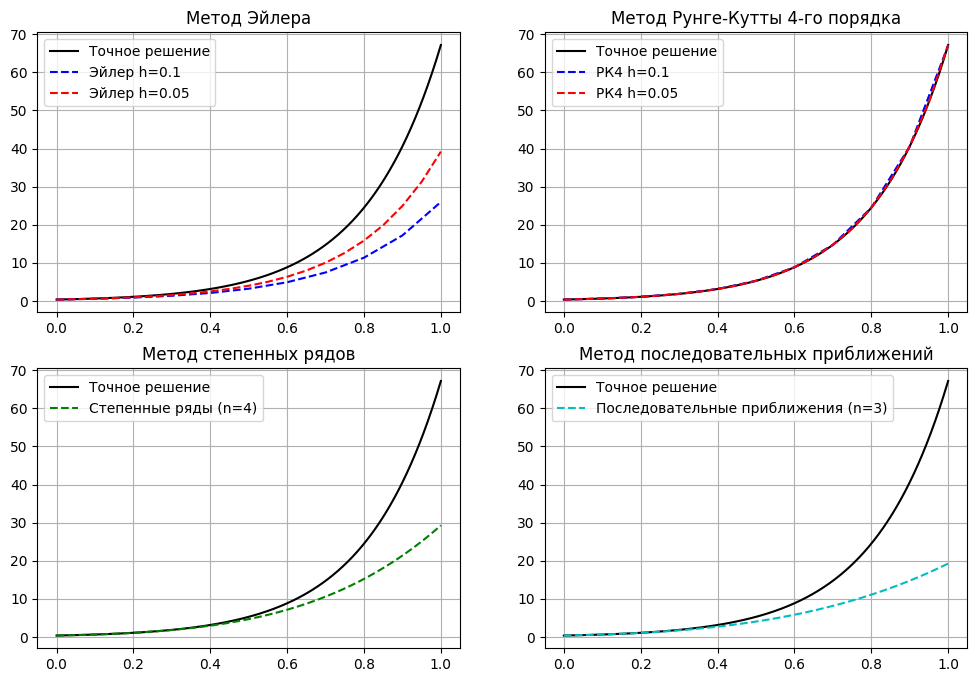

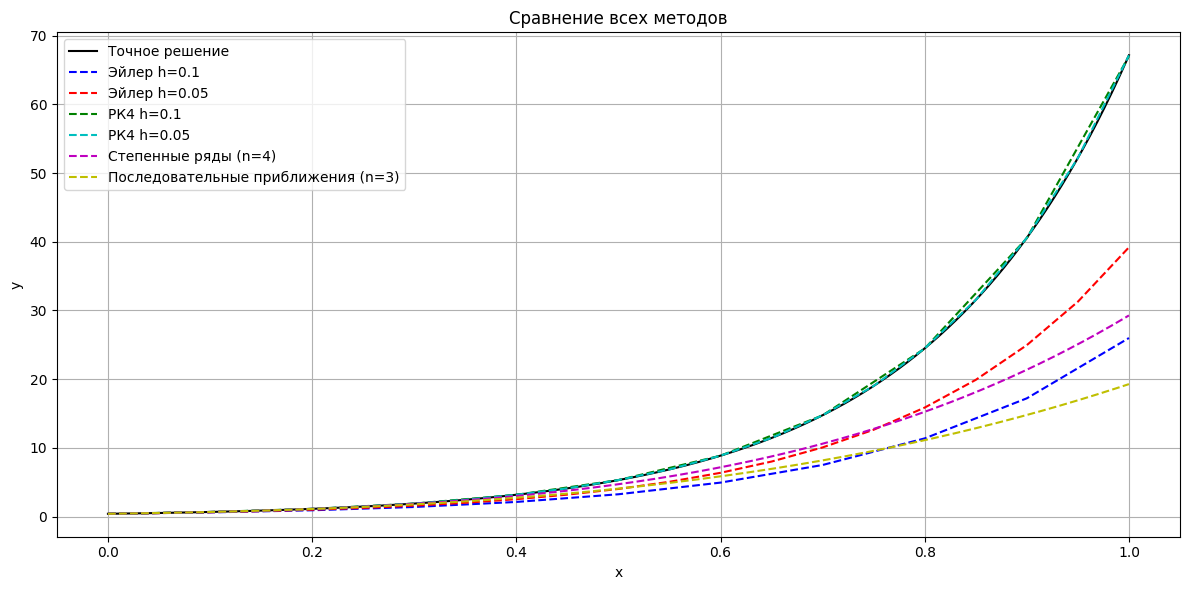

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import symbols, series, exp
from sympy.utilities.lambdify import lambdify


x0 = 0
y0 = 0.4
a = 0
b = 1
h1 = 0.1
h2 = 0.05


def f(x, y):
    return x**2 + x + 5*y


def euler_method(f, x0, y0, h, b):
    n = int((b - x0) / h)
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)
    x[0] = x0
    y[0] = y0

    for i in range(n):
        x[i+1] = x[i] + h
        y[i+1] = y[i] + h * f(x[i], y[i])

    return x, y


def runge_kutta_4(f, x0, y0, h, b):
    n = int((b - x0) / h)
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)
    x[0] = x0
    y[0] = y0

    for i in range(n):
        k1 = f(x[i], y[i])
        k2 = f(x[i] + h/2, y[i] + h*k1/2)
        k3 = f(x[i] + h/2, y[i] + h*k2/2)
        k4 = f(x[i] + h, y[i] + h*k3)

        x[i+1] = x[i] + h
        y[i+1] = y[i] + h * (k1 + 2*k2 + 2*k3 + k4) / 6

    return x, y


def power_series_method(x_values):
    # Используем символьное вычисление для нахождения коэффициентов ряда
    x, t = symbols('x t')

    # Исходное дифференциальное уравнение: y' = x^2 + x + 5y, y(0) = 0.4

    # Вычисляем коэффициенты ряда Тейлора
    a0 = 0.4  # y(0)
    a1 = f(0, a0)  # y'(0) = f(0, 0.4) = 0^2 + 0 + 5*0.4 = 2

    # Для a2 нам нужно y''(x) = d/dx(x^2 + x + 5y) = 2x + 1 + 5y'
    # y''(0) = 2*0 + 1 + 5*a1 = 1 + 5*2 = 11
    a2 = (1 + 5*a1) / 2  # деление на 2 для 2!

    # Для a3 нам нужно y'''(x) = d/dx(2x + 1 + 5y') = 2 + 5y''
    # y'''(0) = 2 + 5*a2*2 = 2 + 5*11 = 2 + 55 = 57
    a3 = (2 + 5*2*a2) / 6  # деление на 6 для 3!

    # Для a4 нам нужно y^(4)(x) = d/dx(2 + 5y'') = 5y'''
    # y^(4)(0) = 5*a3*6 = 5*57 = 285
    a4 = (5*6*a3) / 24  # деление на 24 для 4!

    # Создаем функцию для вычисления значений
    def y_series(x):
        return a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4

    # Вычисляем значения для заданных x
    y_values = [y_series(xi) for xi in x_values]

    return y_values


def successive_approximations(x_values):
    # Начальное приближение y₀(x) = 0.4 (начальное условие)
    def y0(x):
        return 0.4

    # Формула последовательных приближений:
    # y_{n+1}(x) = y(0) + ∫[0,x] f(t, y_n(t)) dt

    # Первое приближение
    def y1(x):
        # y₁(x) = 0.4 + ∫[0,x] (t² + t + 5*0.4) dt
        return 0.4 + x**3/3 + x**2/2 + 2*x

    # Второе приближение
    def y2(x):
        # y₂(x) = 0.4 + ∫[0,x] (t² + t + 5*y₁(t)) dt
        # Заменяем y₁(t) соответствующим выражением
        result = 0.4 + x**3/3 + x**2/2
        result += 5 * (0.4*x + x**4/12 + x**3/6 + x**2)
        return result

    # Третье приближение
    def y3(x):
        # y₃(x) = 0.4 + ∫[0,x] (t² + t + 5*y₂(t)) dt
        # Это довольно сложное выражение, поэтому мы используем численное интегрирование

        # Для простоты реализации используем трапецеидальное правило
        def integrand(t):
            return t**2 + t + 5*y2(t)

        if x == 0:
            return 0.4

        num_steps = 100
        t_values = np.linspace(0, x, num_steps)
        dt = t_values[1] - t_values[0]
        integral = np.sum(integrand(t_values[:-1]) + integrand(t_values[1:])) * dt / 2

        return 0.4 + integral

    # Вычисляем значения для третьего приближения
    y_values = [y3(xi) for xi in x_values]

    return y_values

# Решение с помощью solve_ivp для сравнения ("точное" решение)
def exact_solution(x_values):
    sol = solve_ivp(lambda t, y: f(t, y), [a, b], [y0], t_eval=x_values, method='RK45', rtol=1e-8)
    return sol.y[0]

# Вычисление погрешности
def calculate_error(approx_solution, exact_solution):
    return np.max(np.abs(approx_solution - exact_solution))

# Основная функция для проведения расчетов и визуализации
def solve_and_visualize():
    # Создаем точки для графиков
    x_dense = np.linspace(a, b, 1000)
    exact_sol = exact_solution(x_dense)

    # Метод Эйлера с разными шагами
    x_euler_h1, y_euler_h1 = euler_method(f, x0, y0, h1, b)
    x_euler_h2, y_euler_h2 = euler_method(f, x0, y0, h2, b)

    # Метод Рунге-Кутты с разными шагами
    x_rk4_h1, y_rk4_h1 = runge_kutta_4(f, x0, y0, h1, b)
    x_rk4_h2, y_rk4_h2 = runge_kutta_4(f, x0, y0, h2, b)

    # Метод степенных рядов
    y_power_series = power_series_method(x_dense)

    # Метод последовательных приближений
    y_successive = successive_approximations(x_dense)

    # Расчет погрешностей
    euler_h1_error = calculate_error(np.interp(x_dense, x_euler_h1, y_euler_h1), exact_sol)
    euler_h2_error = calculate_error(np.interp(x_dense, x_euler_h2, y_euler_h2), exact_sol)
    rk4_h1_error = calculate_error(np.interp(x_dense, x_rk4_h1, y_rk4_h1), exact_sol)
    rk4_h2_error = calculate_error(np.interp(x_dense, x_rk4_h2, y_rk4_h2), exact_sol)
    power_series_error = calculate_error(np.array(y_power_series), exact_sol)
    successive_error = calculate_error(np.array(y_successive), exact_sol)

    # Вывод информации о погрешностях
    print("Погрешности методов:")
    print(f"Метод Эйлера (h = {h1}): {euler_h1_error:.8f}")
    print(f"Метод Эйлера (h = {h2}): {euler_h2_error:.8f}")
    print(f"Метод Рунге-Кутты 4-го порядка (h = {h1}): {rk4_h1_error:.8f}")
    print(f"Метод Рунге-Кутты 4-го порядка (h = {h2}): {rk4_h2_error:.8f}")
    print(f"Метод степенных рядов (n = 4): {power_series_error:.8f}")
    print(f"Метод последовательных приближений (n = 3): {successive_error:.8f}")

    # Создание таблицы значений для отчета
    x_report = np.linspace(a, b, 11)  # 11 точек от 0 до 1 с шагом 0.1

    # Получаем значения для каждого метода в контрольных точках
    exact_values = exact_solution(x_report)
    euler_h1_values = np.interp(x_report, x_euler_h1, y_euler_h1)
    euler_h2_values = np.interp(x_report, x_euler_h2, y_euler_h2)
    rk4_h1_values = np.interp(x_report, x_rk4_h1, y_rk4_h1)
    rk4_h2_values = np.interp(x_report, x_rk4_h2, y_rk4_h2)
    power_series_values = np.array([power_series_method([x])[0] for x in x_report])
    successive_values = np.array([successive_approximations([x])[0] for x in x_report])

    # Вывод таблицы значений
    print("\nТаблица значений:")
    print("   x   |   Точное   |  Эйлер h=0.1 |  Эйлер h=0.05 |   РК4 h=0.1  |  РК4 h=0.05  | Степ. ряды | Посл. прибл.")
    print("-------|------------|--------------|--------------|--------------|--------------|------------|-------------")
    for i, x in enumerate(x_report):
        print(f"{x:.1f}   | {exact_values[i]:.8f} | {euler_h1_values[i]:.8f} | {euler_h2_values[i]:.8f} | {rk4_h1_values[i]:.8f} | {rk4_h2_values[i]:.8f} | {power_series_values[i]:.8f} | {successive_values[i]:.8f}")

    # Построение графиков
    plt.figure(figsize=(12, 8))

    # График для метода Эйлера
    plt.subplot(2, 2, 1)
    plt.plot(x_dense, exact_sol, 'k-', label='Точное решение')
    plt.plot(x_euler_h1, y_euler_h1, 'b--', label=f'Эйлер h={h1}')
    plt.plot(x_euler_h2, y_euler_h2, 'r--', label=f'Эйлер h={h2}')
    plt.title('Метод Эйлера')
    plt.legend()
    plt.grid(True)

    # График для метода Рунге-Кутты
    plt.subplot(2, 2, 2)
    plt.plot(x_dense, exact_sol, 'k-', label='Точное решение')
    plt.plot(x_rk4_h1, y_rk4_h1, 'b--', label=f'РК4 h={h1}')
    plt.plot(x_rk4_h2, y_rk4_h2, 'r--', label=f'РК4 h={h2}')
    plt.title('Метод Рунге-Кутты 4-го порядка')
    plt.legend()
    plt.grid(True)

    # График для метода степенных рядов
    plt.subplot(2, 2, 3)
    plt.plot(x_dense, exact_sol, 'k-', label='Точное решение')
    plt.plot(x_dense, y_power_series, 'g--', label='Степенные ряды (n=4)')
    plt.title('Метод степенных рядов')
    plt.legend()
    plt.grid(True)

    # График для метода последовательных приближений
    plt.subplot(2, 2, 4)
    plt.plot(x_dense, exact_sol, 'k-', label='Точное решение')
    plt.plot(x_dense, y_successive, 'c--', label='Последовательные приближения (n=3)')
    plt.title('Метод последовательных приближений')
    plt.legend()
    plt.grid(True)

    # Общий график для сравнения всех методов
    plt.figure(figsize=(12, 6))
    plt.plot(x_dense, exact_sol, 'k-', label='Точное решение')
    plt.plot(x_euler_h1, y_euler_h1, 'b--', label=f'Эйлер h={h1}')
    plt.plot(x_euler_h2, y_euler_h2, 'r--', label=f'Эйлер h={h2}')
    plt.plot(x_rk4_h1, y_rk4_h1, 'g--', label=f'РК4 h={h1}')
    plt.plot(x_rk4_h2, y_rk4_h2, 'c--', label=f'РК4 h={h2}')
    plt.plot(x_dense, y_power_series, 'm--', label='Степенные ряды (n=4)')
    plt.plot(x_dense, y_successive, 'y--', label='Последовательные приближения (n=3)')
    plt.title('Сравнение всех методов')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    solve_and_visualize()